# Домашнее задание 2. Библиотеки для визуализаций в Python

Задание выполнил(а):

    Петр Бондарев

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания). Всего в сумме можно получить, если правильно решить все задания, 10 баллов.

## Раздел 1. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'

### Задание 1 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку.. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

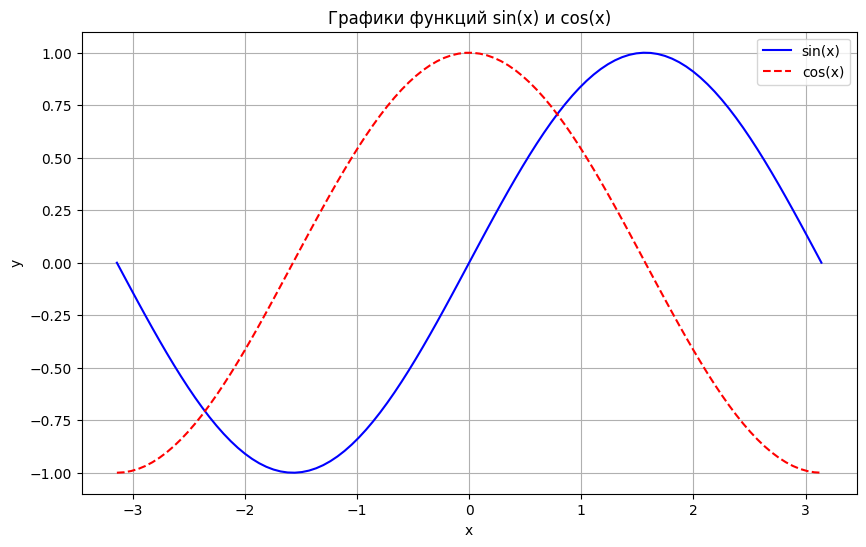

In [ ]:
# Создаём массив из 100 точек на интервале от -π до π
x = np.linspace(-np.pi, np.pi, 100)

# Вычисляем значения sin(x) и cos(x)
y_sin = np.sin(x)
y_cos = np.cos(x)

# Создаём график
plt.figure(figsize=(10, 6))

# Строим sin(x) сплошной линией синего цвета
plt.plot(x, y_sin, color='blue', linestyle='-', label='sin(x)')

# Строим cos(x) пунктирной линией красного цвета
plt.plot(x, y_cos, color='red', linestyle='--', label='cos(x)')

# Добавляем заголовок и подписи осей
plt.title('Графики функций sin(x) и cos(x)')
plt.xlabel('x')
plt.ylabel('y')

# Добавляем легенду и сетку
plt.legend()
plt.grid(True)

# Отображаем график
plt.show()

In [ ]:
# то что должно получиться


### Задание 2 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

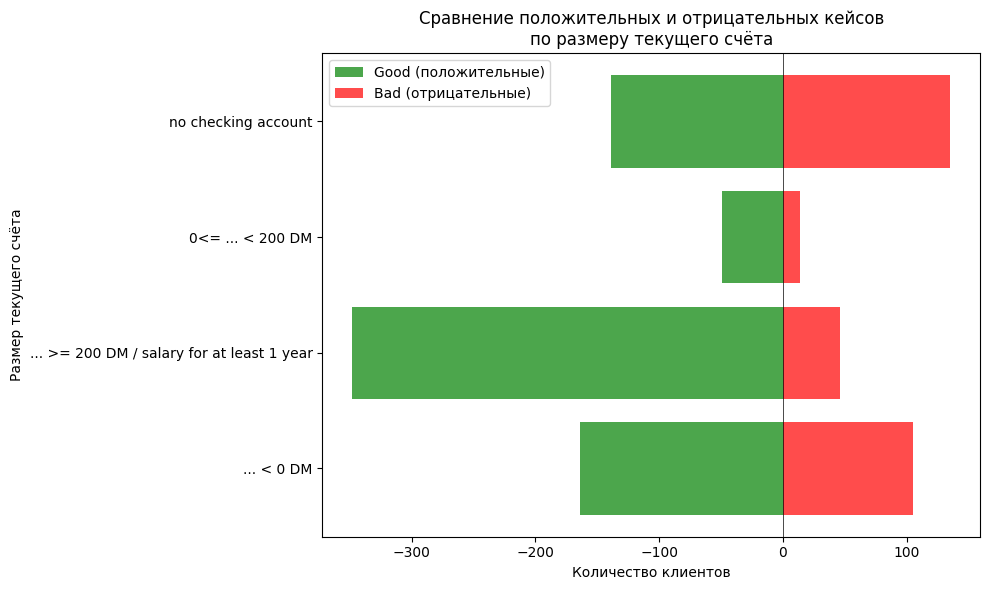

In [20]:
# Загружаем данные
df = pd.read_csv(GERMAN_CREDIT)

# Группируем данные по текущему счёту и кредитному рейтингу
grouped = df.groupby(['status', 'credit_risk']).size().unstack(fill_value=0)

# Создаём зеркальные горизонтальные гистограммы
fig, ax = plt.subplots(figsize=(10, 6))

# Получаем категории
categories = grouped.index.tolist()
y_pos = np.arange(len(categories))

# Положительные кейсы (good) - влево (отрицательные значения)
good_values = -grouped['good'].values
# Отрицательные кейсы (bad) - вправо
bad_values = grouped['bad'].values

# Строим гистограммы
ax.barh(y_pos, good_values, color='green', alpha=0.7, label='Good (положительные)')
ax.barh(y_pos, bad_values, color='red', alpha=0.7, label='Bad (отрицательные)')

# Настраиваем оси
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.set_xlabel('Количество клиентов')
ax.set_ylabel('Размер текущего счёта')
ax.set_title('Сравнение положительных и отрицательных кейсов\nпо размеру текущего счёта')

# Добавляем вертикальную линию в центре
ax.axvline(x=0, color='black', linewidth=0.5)

# Добавляем легенду
ax.legend()

plt.tight_layout()
plt.show()

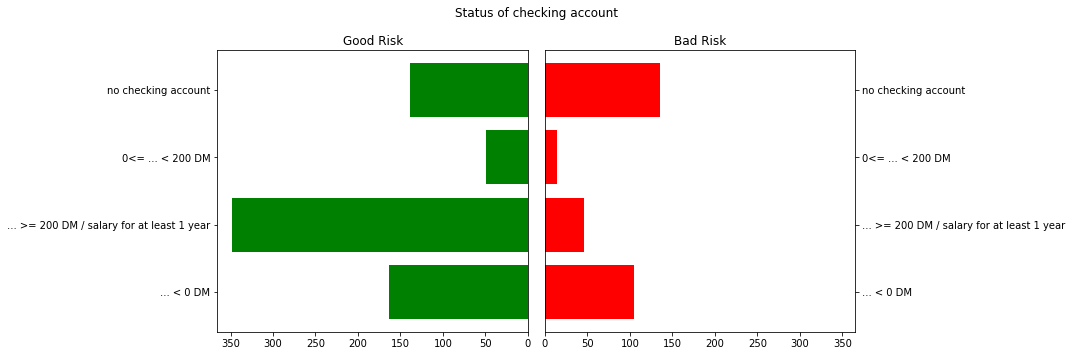

In [ ]:
# то что должно получиться

### Задание 3  (0.5 балла)

In [ ]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

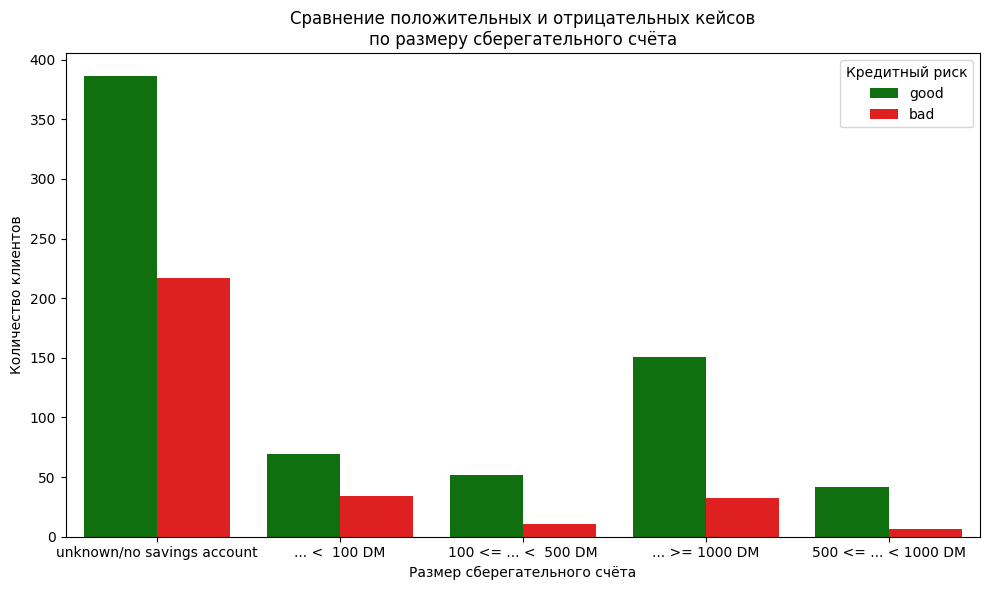

In [19]:
# Строим гистограмму с помощью seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='savings', hue='credit_risk', palette=['green', 'red'])

plt.title('Сравнение положительных и отрицательных кейсов\nпо размеру сберегательного счёта')
plt.xlabel('Размер сберегательного счёта')
plt.ylabel('Количество клиентов')
plt.legend(title='Кредитный риск')

plt.tight_layout()
plt.show()

# Комментарий:
# Seaborn значительно проще в использовании - всего одна функция countplot 
# вместо ручной группировки и построения. С точки зрения восприятия результата,
# вертикальные столбцы в seaborn более привычны для сравнения категорий.

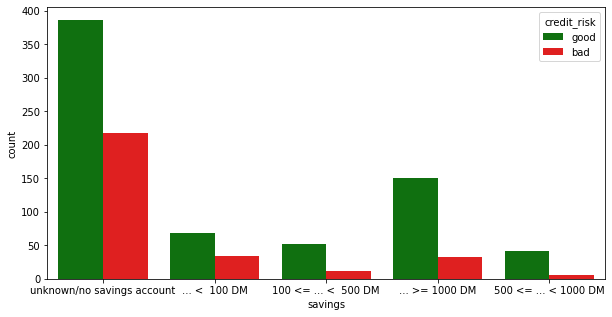

In [ ]:
# то что должно получиться

### Задание 4  (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

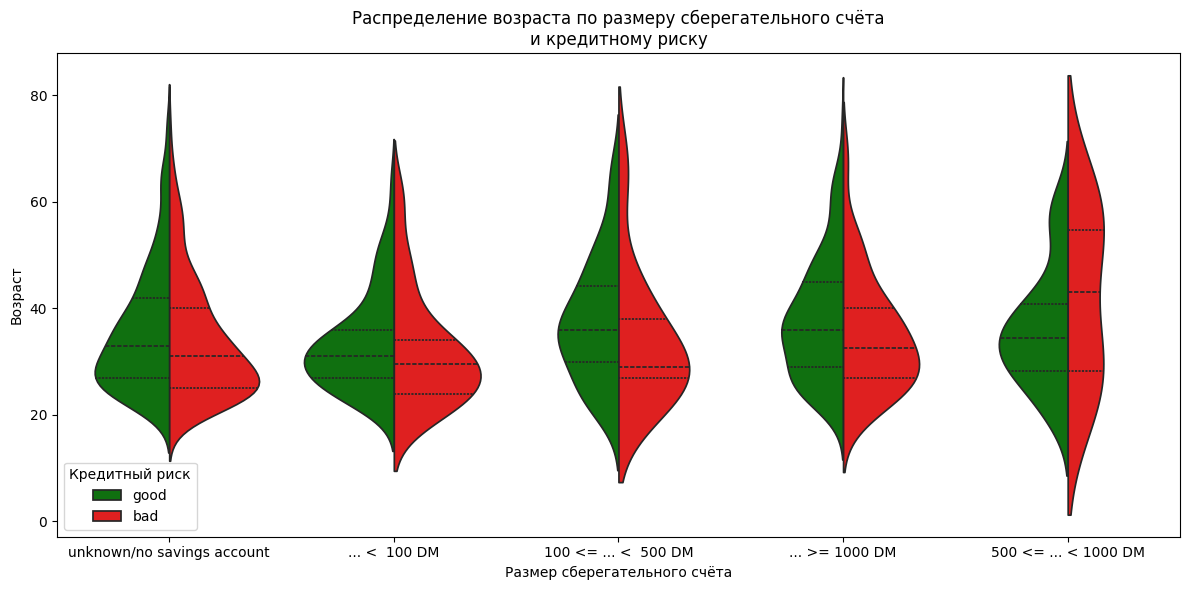

In [15]:
# Строим split violin plot с распределением по возрасту для каждого размера сберегательного счёта
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='savings', y='age', hue='credit_risk', 
               split=True, palette={'bad': 'red', 'good': 'green'}, inner='quart')

plt.title('Распределение возраста по размеру сберегательного счёта\nи кредитному риску')
plt.xlabel('Размер сберегательного счёта')
plt.ylabel('Возраст')
plt.legend(title='Кредитный риск')

plt.tight_layout()
plt.show()

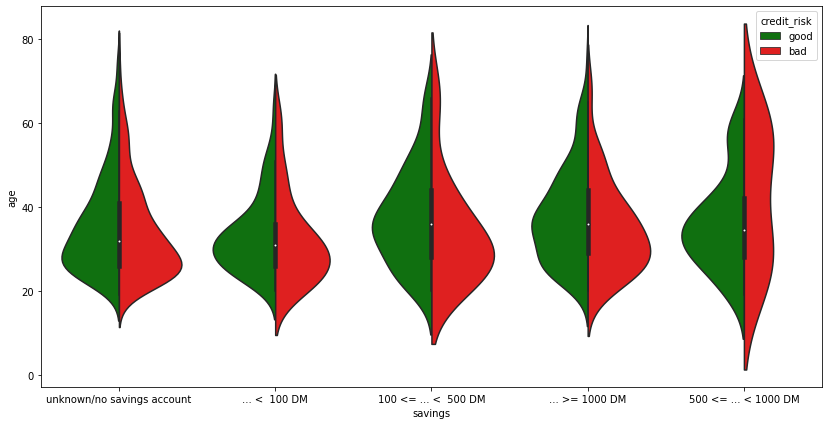

In [ ]:
# то что должно получиться

### Задание 5  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

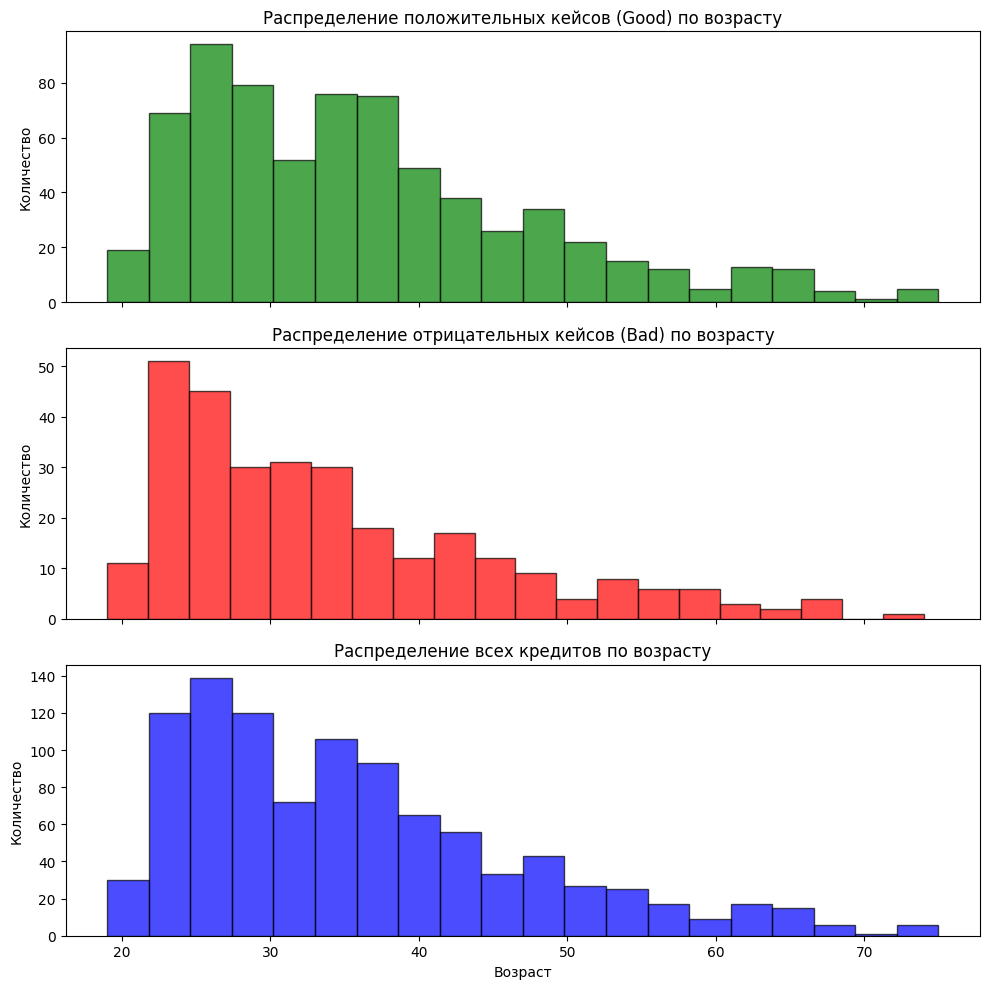

In [13]:
# Создаём три гистограммы друг над другом
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Фильтруем данные
good_ages = df[df['credit_risk'] == 'good']['age']
bad_ages = df[df['credit_risk'] == 'bad']['age']
all_ages = df['age']

# Гистограмма для положительных кейсов
axes[0].hist(good_ages, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение положительных кейсов (Good) по возрасту')

# Гистограмма для отрицательных кейсов
axes[1].hist(bad_ages, bins=20, color='red', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение отрицательных кейсов (Bad) по возрасту')

# Гистограмма для всех кредитов
axes[2].hist(all_ages, bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Количество')
axes[2].set_title('Распределение всех кредитов по возрасту')

plt.tight_layout()
plt.show()

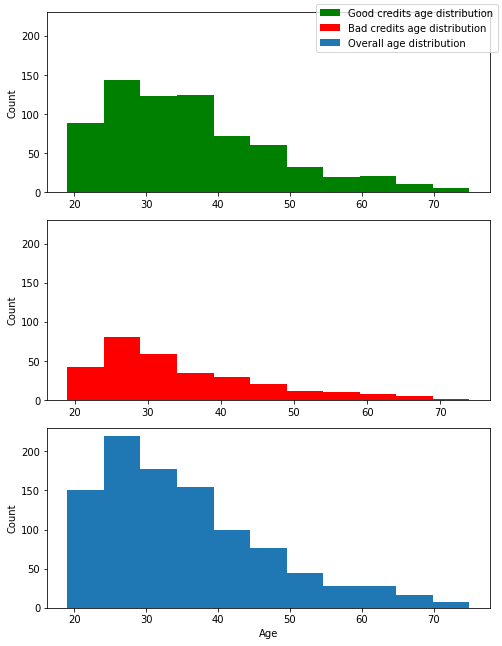

In [ ]:
# то что должно получиться

### Задание 6  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

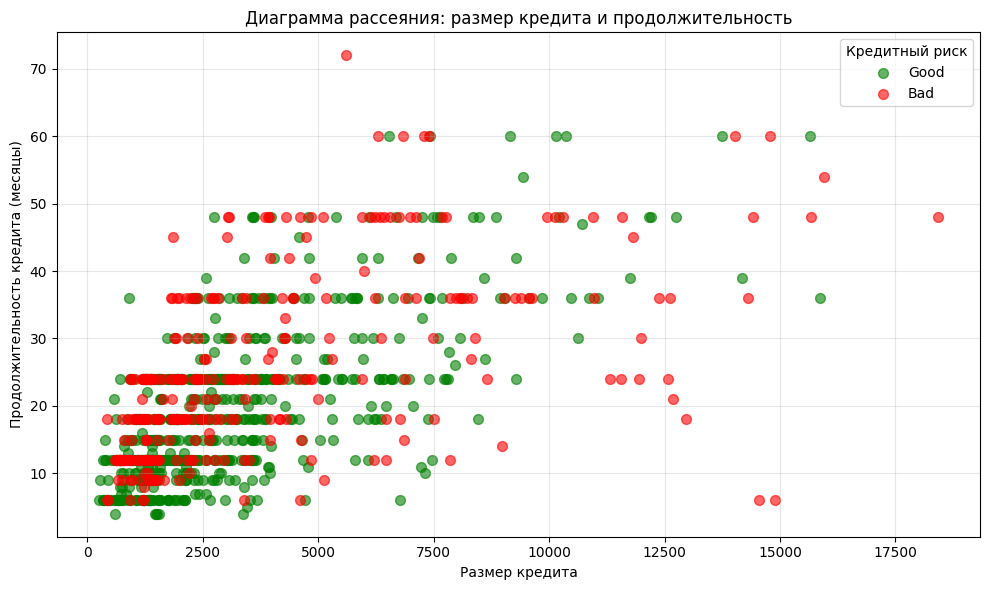

In [21]:
# Диаграмма рассеяния: размер кредита vs продолжительность
plt.figure(figsize=(10, 6))

# Разделяем данные по кредитному риску
good = df[df['credit_risk'] == 'good']
bad = df[df['credit_risk'] == 'bad']

# Строим точки для каждой группы
plt.scatter(good['amount'], good['duration'], c='green', alpha=0.6, label='Good', s=50)
plt.scatter(bad['amount'], bad['duration'], c='red', alpha=0.6, label='Bad', s=50)

plt.xlabel('Размер кредита')
plt.ylabel('Продолжительность кредита (месяцы)')
plt.title('Диаграмма рассеяния: размер кредита и продолжительность')
plt.legend(title='Кредитный риск')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

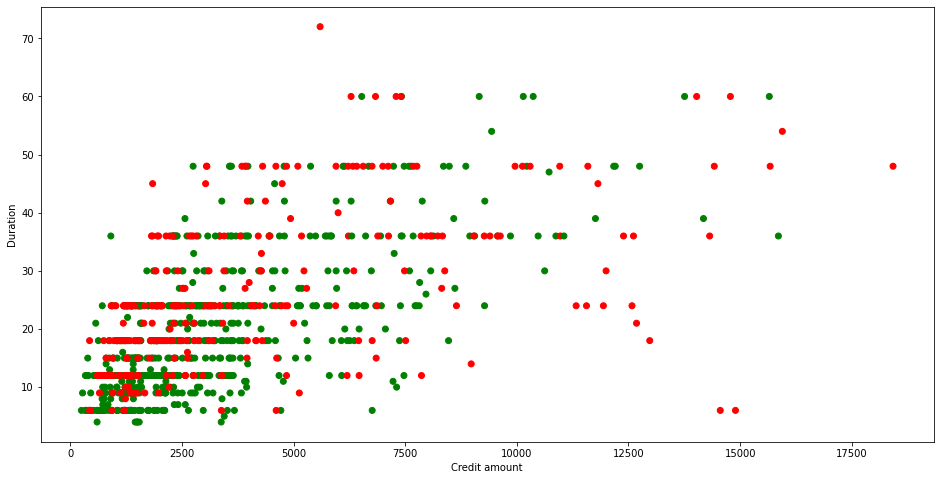

In [ ]:
# то что должно получиться

### Задание 7  (0.5 балла)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

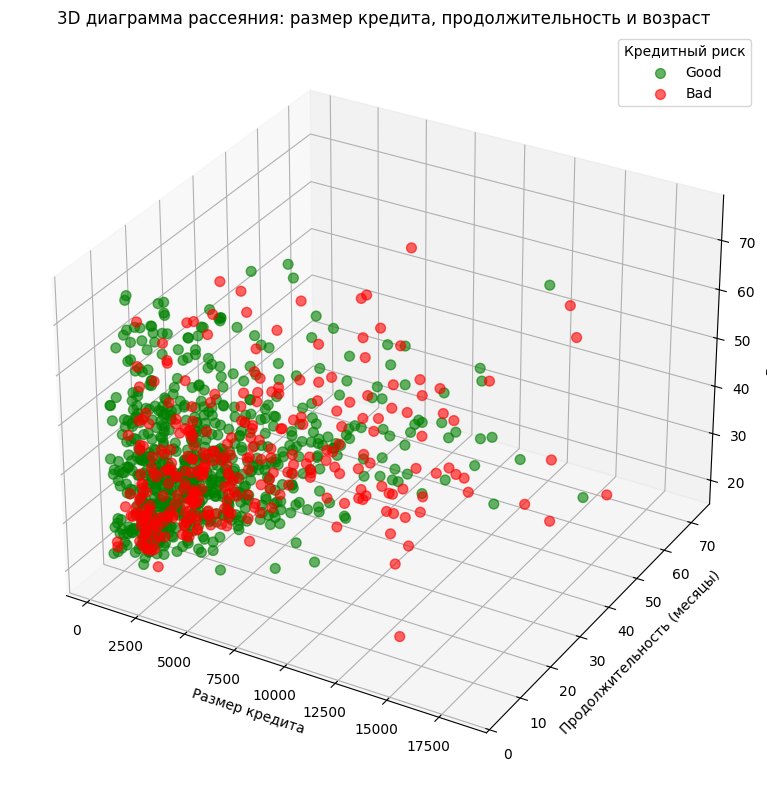

In [18]:
# 3D диаграмма рассеяния
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Разделяем данные по кредитному риску
good = df[df['credit_risk'] == 'good']
bad = df[df['credit_risk'] == 'bad']

# Строим 3D точки
ax.scatter(good['amount'], good['duration'], good['age'], 
           c='green', alpha=0.6, label='Good', s=50)
ax.scatter(bad['amount'], bad['duration'], bad['age'], 
           c='red', alpha=0.6, label='Bad', s=50)

ax.set_xlabel('Размер кредита')
ax.set_ylabel('Продолжительность (месяцы)')
ax.set_zlabel('Возраст')
ax.set_title('3D диаграмма рассеяния: размер кредита, продолжительность и возраст')
ax.legend(title='Кредитный риск')

plt.tight_layout()
plt.show()

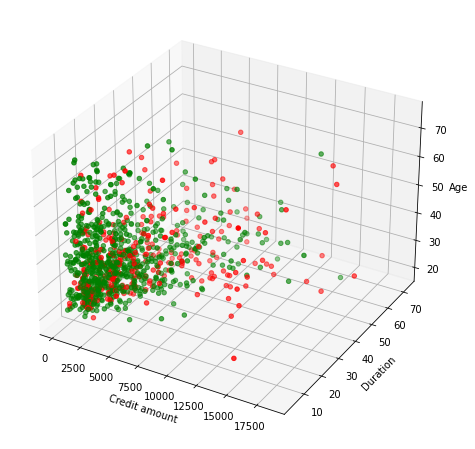

In [ ]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  

**Сравнение 2D и 3D визуализаций:**

*Преимущества 2D:*
- Легче воспринимать и анализировать
- Проще определить точные значения
- Лучше подходит для печати и презентаций

*Преимущества 3D:*
- Можно отобразить больше измерений одновременно
- Более наглядно показывает сложные зависимости

*Недостатки 3D:*
- Сложнее точно оценить значения
- Точки могут перекрывать друг друга

**Бизнес-выводы:**
- Клиенты с плохим кредитным рейтингом чаще берут кредиты на более длительный срок и большие суммы
- Молодые клиенты чаще имеют отрицательный кредитный рейтинг
- Для минимизации рисков банку следует более тщательно проверять клиентов, запрашивающих крупные долгосрочные кредиты

## Раздел 2. Визуализации в датасете Netflix

В данном разделе вы продолжите практиковаться в визуализациях и поработаете с более сложными графиками и инструментами.

Все технические рекомендации остаются неизменными с прошлого раздела.

In [8]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'

### Задание 1  (0.5 балла)

Прочитайте средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов содержат пропуски в столбце `director`.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

Количество пропусков в колонке director: 2389


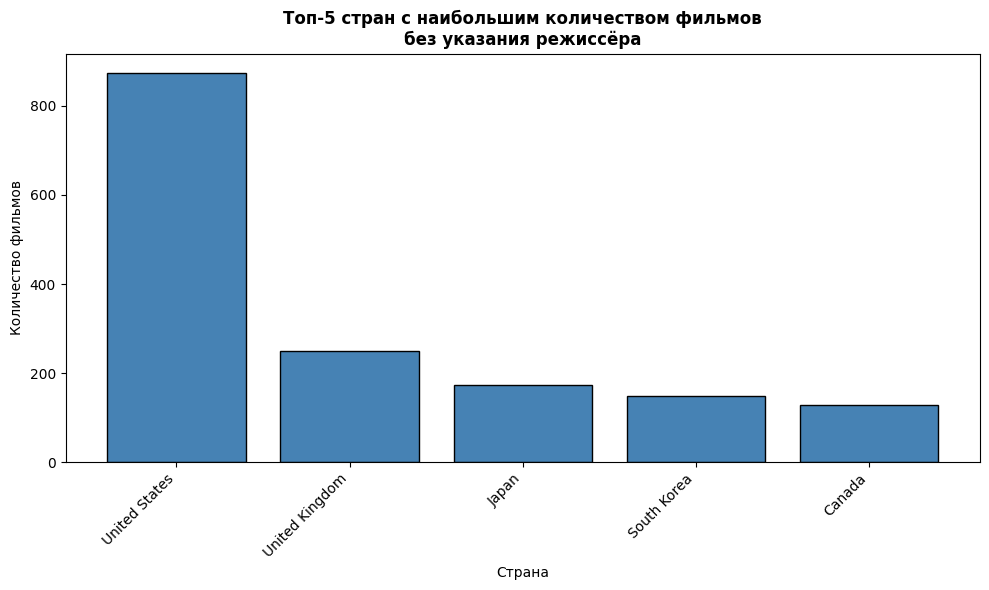

In [9]:
# Загружаем данные Netflix
netflix_df = pd.read_csv(NETFLIX_TITLES)

# Считаем количество пропусков в колонке director
nan_count = netflix_df['director'].isna().sum()
print(f'Количество пропусков в колонке director: {nan_count}')

# Фильтруем фильмы с пропусками в director
missing_director = netflix_df[netflix_df['director'].isna()]

# Считаем количество по странам (разбиваем, т.к. может быть несколько стран)
country_counts = missing_director['country'].dropna().str.split(', ').explode().value_counts()

# Топ-5 стран
top_5_countries = country_counts.head(5)

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(top_5_countries.index, top_5_countries.values, color='steelblue', edgecolor='black')

plt.title('Топ-5 стран с наибольшим количеством фильмов\nбез указания режиссёра', fontweight='bold')
plt.xlabel('Страна')
plt.ylabel('Количество фильмов')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Задание 2 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

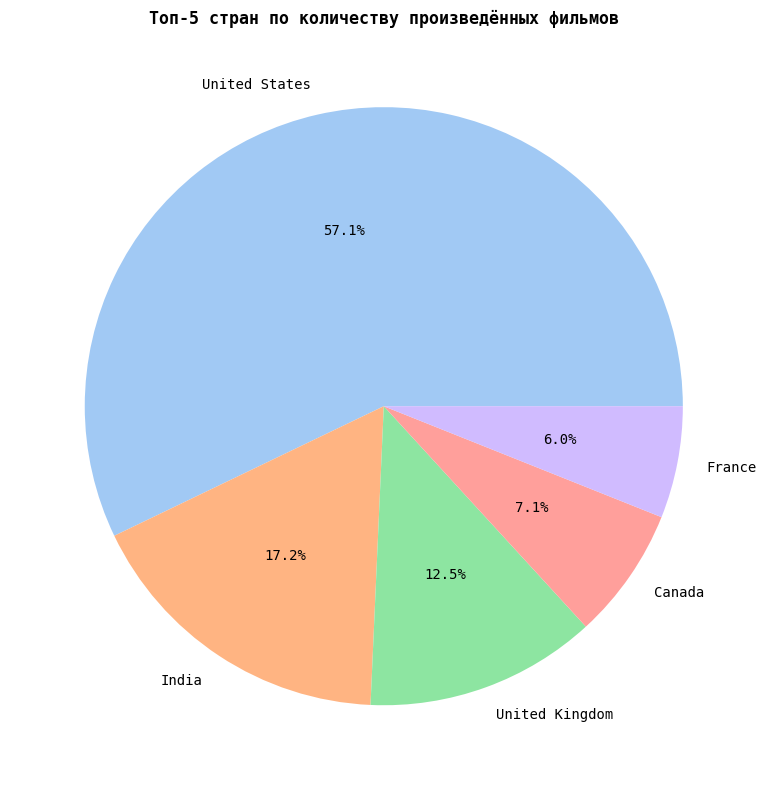

In [10]:
# Подсчитываем количество фильмов по странам (разбиваем множественные страны)
all_countries = netflix_df['country'].dropna().str.split(', ').explode().value_counts()

# Топ-5 стран
top_5 = all_countries.head(5)

# Цвета pastel из seaborn
colors = sns.color_palette('pastel')[0:5]

# Строим круговую диаграмму
plt.figure(figsize=(10, 8))
plt.pie(top_5.values, labels=top_5.index, autopct='%1.1f%%', 
        colors=colors,
        textprops={'family': 'monospace'})

plt.title('Топ-5 стран по количеству произведённых фильмов', 
          family='monospace', fontweight='bold')

plt.tight_layout()
plt.show()

### Задание 3 (1 балл)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно.*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

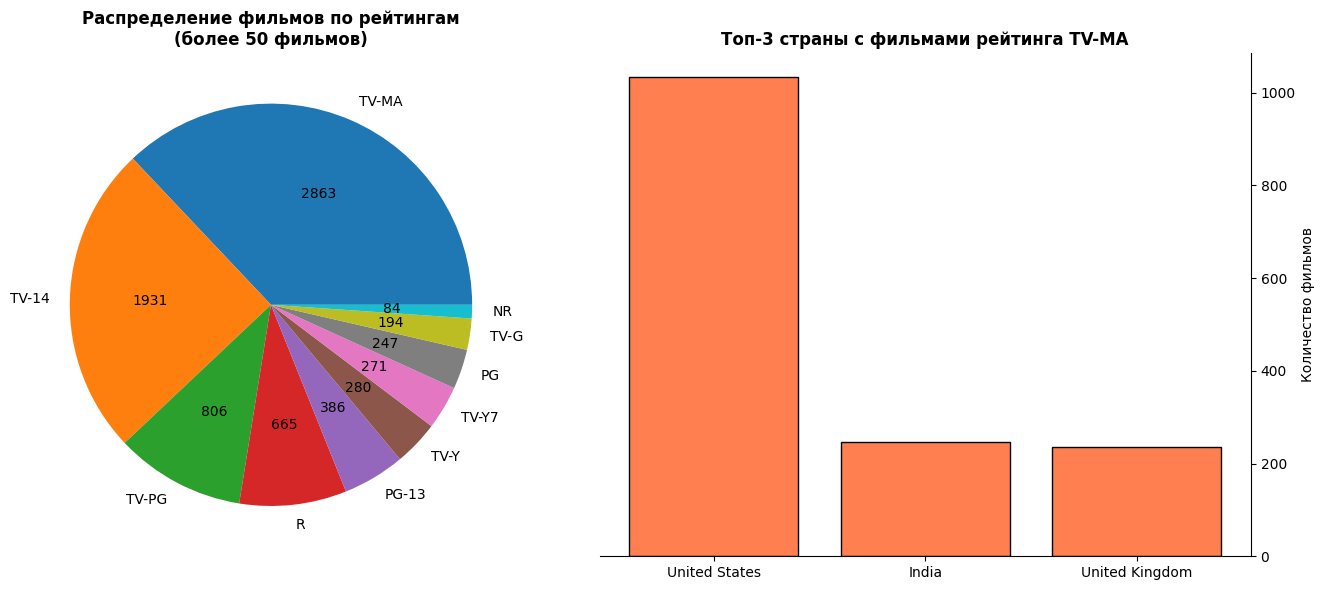

In [11]:
# Подсчитываем количество фильмов по рейтингам
rating_counts = netflix_df['rating'].value_counts()

# Фильтруем рейтинги с количеством >= 50
rating_counts_filtered = rating_counts[rating_counts >= 50]

# Для TV-MA: топ-3 страны
tv_ma_films = netflix_df[netflix_df['rating'] == 'TV-MA']
tv_ma_countries = tv_ma_films['country'].dropna().str.split(', ').explode().value_counts().head(3)

# Создаём subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Первый график - круговая диаграмма рейтингов
axes[0].pie(rating_counts_filtered.values, labels=rating_counts_filtered.index, 
            autopct=lambda pct: f'{int(round(pct/100.*sum(rating_counts_filtered.values)))}')
axes[0].set_title('Распределение фильмов по рейтингам\n(более 50 фильмов)', fontweight='bold')

# Второй график - столбчатая диаграмма стран с TV-MA
bars = axes[1].bar(tv_ma_countries.index, tv_ma_countries.values, color='coral', edgecolor='black')
axes[1].set_title('Топ-3 страны с фильмами рейтинга TV-MA', fontweight='bold')

# Ось Y справа
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position('right')
axes[1].set_ylabel('Количество фильмов')

# Убираем подпись оси X
axes[1].set_xlabel('')

# Оставляем только правую и нижнюю границы
axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Задание 4 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

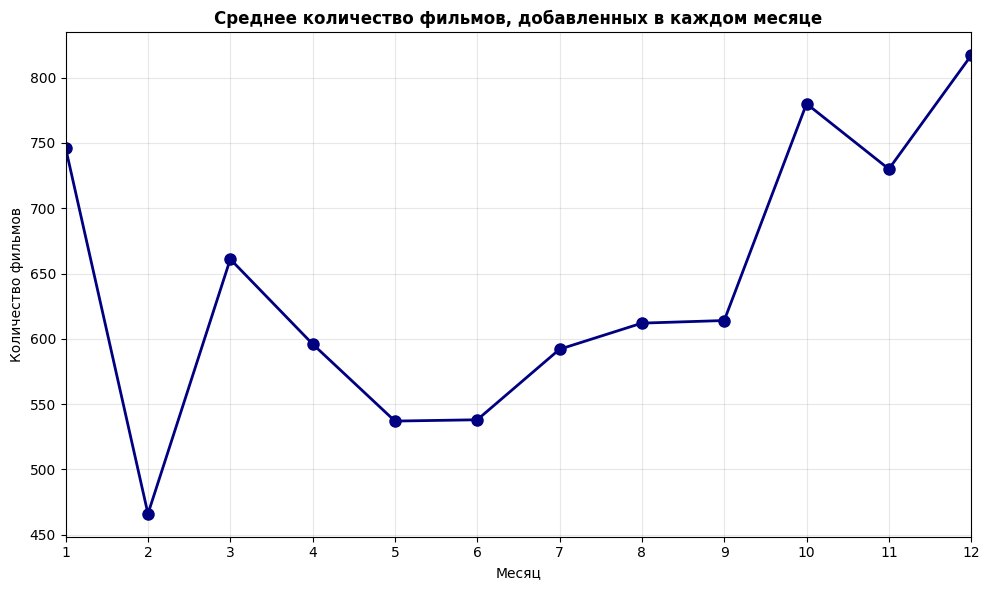

In [12]:
# Преобразуем date_added в datetime
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], errors='coerce')

# Создаём столбцы month и year
netflix_df['month'] = netflix_df['date_added'].dt.month
netflix_df['year'] = netflix_df['date_added'].dt.year

# Считаем среднее количество фильмов по месяцам
monthly_avg = netflix_df.groupby('month').size()

# Строим линейный график
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='navy')

plt.title('Среднее количество фильмов, добавленных в каждом месяце', fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Количество фильмов')

# Настраиваем ось X: от 1 до 12, шаг 1
plt.xticks(range(1, 13))
plt.xlim(1, 12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 5 (1 балл)

Постройте линейный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

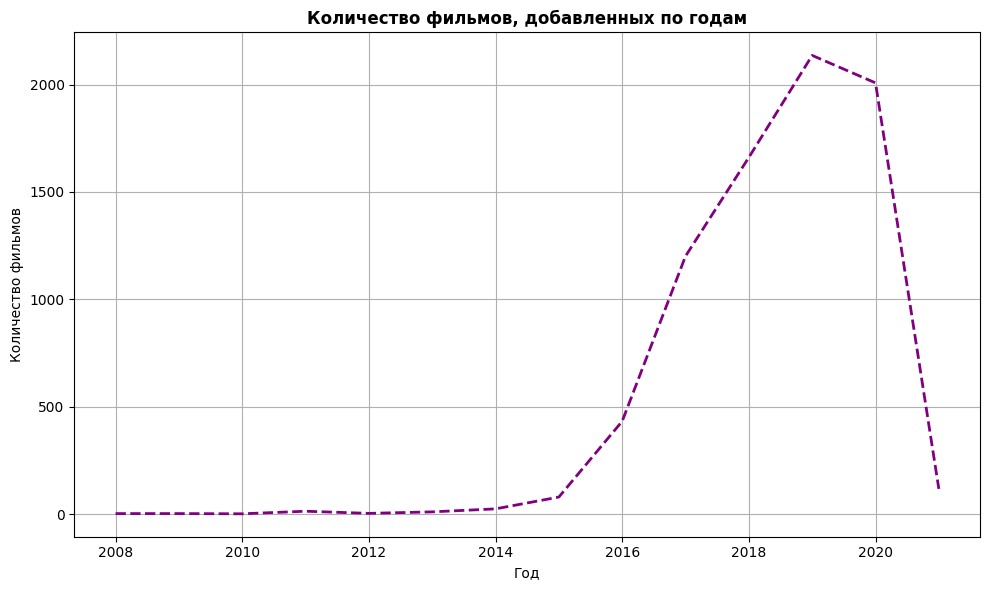

In [13]:
# Считаем количество фильмов по годам
yearly_counts = netflix_df.groupby('year').size()

# Строим линейный график
plt.figure(figsize=(10, 6))
plt.plot(yearly_counts.index, yearly_counts.values, linestyle='--', color='purple', linewidth=2)

plt.title('Количество фильмов, добавленных по годам', fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Количество фильмов')

plt.grid(True)
plt.tight_layout()
plt.show()

### Задание 6 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

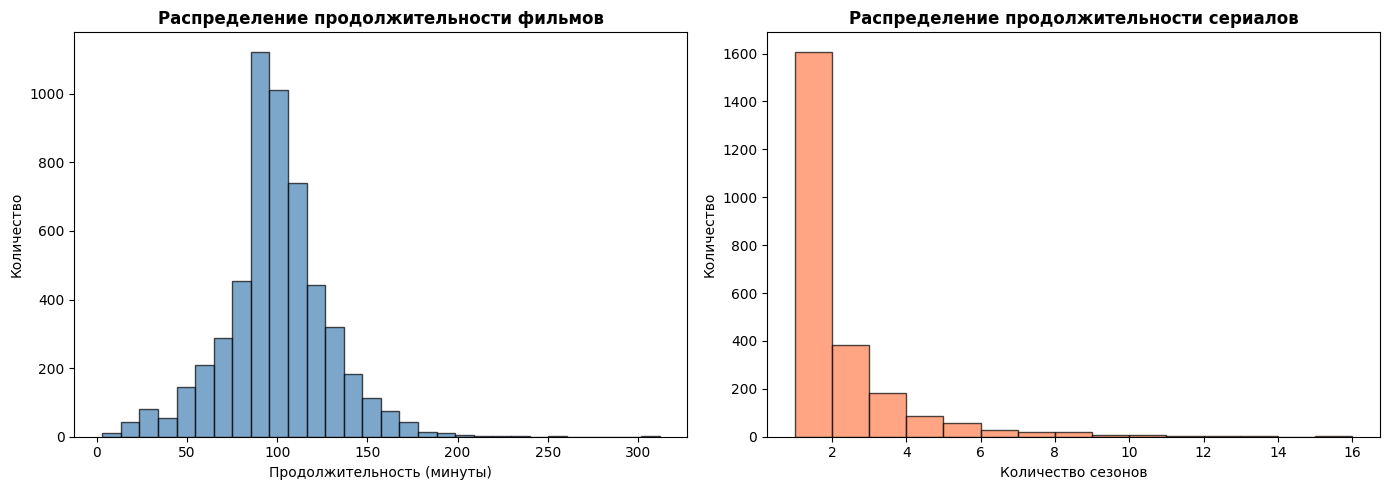

In [14]:
# Извлекаем числа из столбца duration
# Для фильмов (минуты)
netflix_df['min'] = netflix_df[netflix_df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)

# Для сериалов (сезоны)
netflix_df['season'] = netflix_df[netflix_df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

# Создаём subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для фильмов (минуты)
movies_duration = netflix_df['min'].dropna()
axes[0].hist(movies_duration, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение продолжительности фильмов', fontweight='bold')
axes[0].set_xlabel('Продолжительность (минуты)')
axes[0].set_ylabel('Количество')

# Гистограмма для сериалов (сезоны)
shows_duration = netflix_df['season'].dropna()
axes[1].hist(shows_duration, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение продолжительности сериалов', fontweight='bold')
axes[1].set_xlabel('Количество сезонов')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

### Задание 7 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

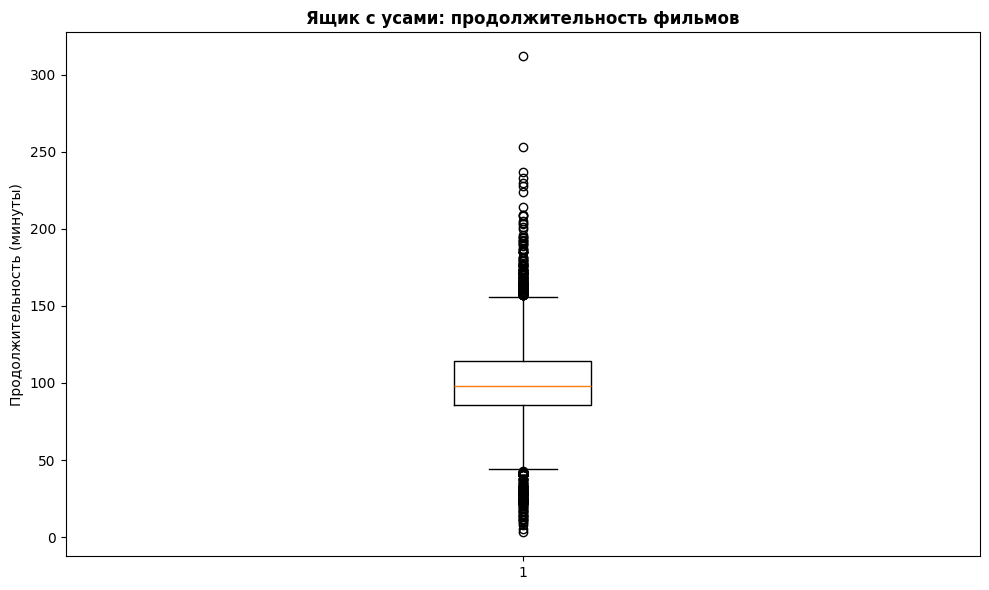

In [15]:
# Box plot для продолжительности фильмов
plt.figure(figsize=(10, 6))
movies_duration = netflix_df['min'].dropna()
plt.boxplot(movies_duration, vert=True)

plt.title('Ящик с усами: продолжительность фильмов', fontweight='bold')
plt.ylabel('Продолжительность (минуты)')

plt.tight_layout()
plt.show()

# Интерпретация:
# Медиана продолжительности фильмов находится примерно на уровне 100 минут.
# Большинство фильмов длятся от 80 до 120 минут (межквартильный размах).
# Есть выбросы - очень короткие фильмы (менее 30 минут) и очень длинные (более 150 минут).

### Задание 8* (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [16]:
# Устанавливаем plotly если нужно
import plotly.express as px
import plotly.graph_objects as go

# Фильтруем данные с 2000 года
netflix_2000 = netflix_df[netflix_df['year'] >= 2000].copy()

# Средняя продолжительность фильмов по годам
movies_avg = netflix_2000[netflix_2000['type'] == 'Movie'].groupby('year')['min'].mean()

# Средняя продолжительность сериалов по годам
shows_avg = netflix_2000[netflix_2000['type'] == 'TV Show'].groupby('year')['season'].mean()

# Создаём DataFrame для plotly
years = sorted(set(movies_avg.index) | set(shows_avg.index))
plot_data = pd.DataFrame({
    'Год': years,
    'Фильмы (мин)': [movies_avg.get(y, 0) for y in years],
    'Сериалы (сезоны)': [shows_avg.get(y, 0) for y in years]
})

# Строим интерактивную диаграмму
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Фильмы (средняя продолжительность, мин)',
    x=plot_data['Год'],
    y=plot_data['Фильмы (мин)'],
    marker_color='steelblue'
))

fig.add_trace(go.Bar(
    name='Сериалы (среднее кол-во сезонов)',
    x=plot_data['Год'],
    y=plot_data['Сериалы (сезоны)'],
    marker_color='coral'
))

fig.update_layout(
    title='Сравнение средней продолжительности фильмов и сериалов по годам (с 2000)',
    xaxis_title='Год',
    yaxis_title='Значение',
    barmode='group'
)

fig.show()